# Project Milestone One: Gathering your Team, Understanding the Problem,  Exploring the Data

#### Due: Midnight on March 29th (with 2-hour grace period)  

#### There will be no late period on this homework, as we need to start manual grading immediately! 



### What We Will Do in This Milestone Assignment

1. You will convene your team and fill out the Team Contract (in the Homework Repo), to be submitted to Gradescope.
2. You must select a team leader for the purpose of submitting this notebook, after the team collaborates to complete the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>link</a> describes how to add group members to your leader's submission. 
3. At the conclusion of your work on this Milestone, you will complete an Individual Evaluation of your team's work (in the Homework Repo) and upload it *individually* to Gradescope.
4. We will follow a simplified version of the **Machine Learning Project Checklist** in Appendix A in our textbook *Hands-On Machine Learning* (pp.779):  

>Part 1:	Frame the problem and look at the big picture  
Part 2: Download and perform preliminary exploration of the data  
Part 3: Clean the Data: Drop, Impute, and Encode   
Part 4: Explore Feature Relationships  
Part 5: Investigate Feature Engineering options to better expose the underlying data patterns  

### The Dataset

All teams will use the same dataset. It is a smaller version of the Zillow housing dataset that was used in the
Zillow Million Dollar Prize which ran on Kaggle in 2017 (sorry, the contest is closed, so you can't win any money
with this project!).  We will try to predict the assessed tax value (`'taxvaluedollarcnt'`) of the property from a large collection
of descriptors. Some features are closely related and some are obviously useless.  There are potential outliers and also quite a few missing values. 

This is a good example of a dataset which has not been predigested for you on Kaggle, and should give you a good chance to
try all the various tools in your toolbox!


In [1]:
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset 

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.** 

For a detailed description of the dataset features, please refer to  **Appendix 1** below. 

**Note:** Do **not** perform a train/test split for this milestone (unlike HOML suggests), since you need to do the split **after** any data preparation and feature engineering. You can wait until Milestone 2 to do the split. 

In [3]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File already exists. Skipping download.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercizing all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data; 
- Create a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:** 

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?

**answer**: The goal of this project is to predict housing prices using property data so Zillow can give more accurate estimates to buyers and sellers to help users make better decisions and builds trust in the platform.


**1.2:**  How will your solution be used?

**answer**: The model would be used to estimate home values for listings and help guide pricing decisions and also help Zillow target the right buyers by highlighting features that matter most in different homes.


**1.3:**  How should success (or failure) be measured?

**answer**: Success can be measured by how close the predicted prices are to actual prices (using metrics like MAE or RMSE). From a business side, success would also mean better user trust, more engagement, and more effective listings.

## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process. 
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [4]:
# Basic overview
df.head()

df.info()

# Summary table for each column
summary = pd.DataFrame({
    "Type": df.dtypes,
    "Missing %": df.isnull().mean() * 100,
    "Unique Values": df.nunique()
})

summary["Missing %"] = summary["Missing %"].round(2)

summary

<class 'pandas.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  finishedsqua

,Type,Missing %,Unique Values
parcelid,int64,0.00,77414
airconditioningtypeid,float64,67.78,5
architecturalstyletypeid,float64,99.73,5
basementsqft,float64,99.94,43
bathroomcnt,float64,0.04,22
bedroomcnt,float64,0.04,16
buildingclasstypeid,float64,99.98,2
buildingqualitytypeid,float64,35.82,12
calculatedbathnbr,float64,0.84,21
decktypeid,float64,99.21,1


In [5]:
df['taxvaluedollarcnt'].describe()

count    7.757800e+04
mean     4.901506e+05
std      6.537979e+05
min      1.000000e+03
25%      2.068985e+05
50%      3.588785e+05
75%      5.690000e+05
max      4.906124e+07
Name: taxvaluedollarcnt, dtype: float64

In [6]:
summary.sort_values("Missing %", ascending=False).head(10)

,Type,Missing %,Unique Values
buildingclasstypeid,float64,99.98,2
finishedsquarefeet13,float64,99.95,13
storytypeid,float64,99.94,1
basementsqft,float64,99.94,43
yardbuildingsqft26,float64,99.91,59
fireplaceflag,object,99.78,1
architecturalstyletypeid,float64,99.73,5
typeconstructiontypeid,float64,99.71,4
finishedsquarefeet6,float64,99.50,350
pooltypeid10,float64,99.40,1


#### **2.A Discussion:** Answer the following questions.

**2.A.1:**  Which features are categorical?

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly. 

**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example. 

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example. 

# Part 2.A Discussion
2.A.1:
Categorical features are variables that represent categories rather than numeric quantities.
In this dataset, these include features with data type 'object', such as neighborhood,
house style, exterior type, sale condition.

2.A.2:
Some features such as an ID column
(such as 'Id') is simply a unique identifier and does not relate to the value of a house.
Including such features could introduce noise rather than useful signal, so they should be removed.

2.A.3:
Certain features may be considered useless due to a high percentage of missing values.
For example, a feature like pool quality or pool count often has a large number of missing
values because most houses do not have pools. If a feature has more than around 40–50%
missing data, it becomes difficult to impute reliably and may not contribute meaningfully
to the model, so it is reasonable to drop it.

2.A.4:
Some features may be useless due to having too many unique values, especially when each
value is nearly unique. For example, an ID or address-related feature would have a unique
value for almost every row. These features do not generalize well and cannot help the model
learn patterns, so they are not useful for prediction and should be removed.
"""

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the **target and three (3)** other interesting-looking features in the dataset (i.e., a total of 4):  
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

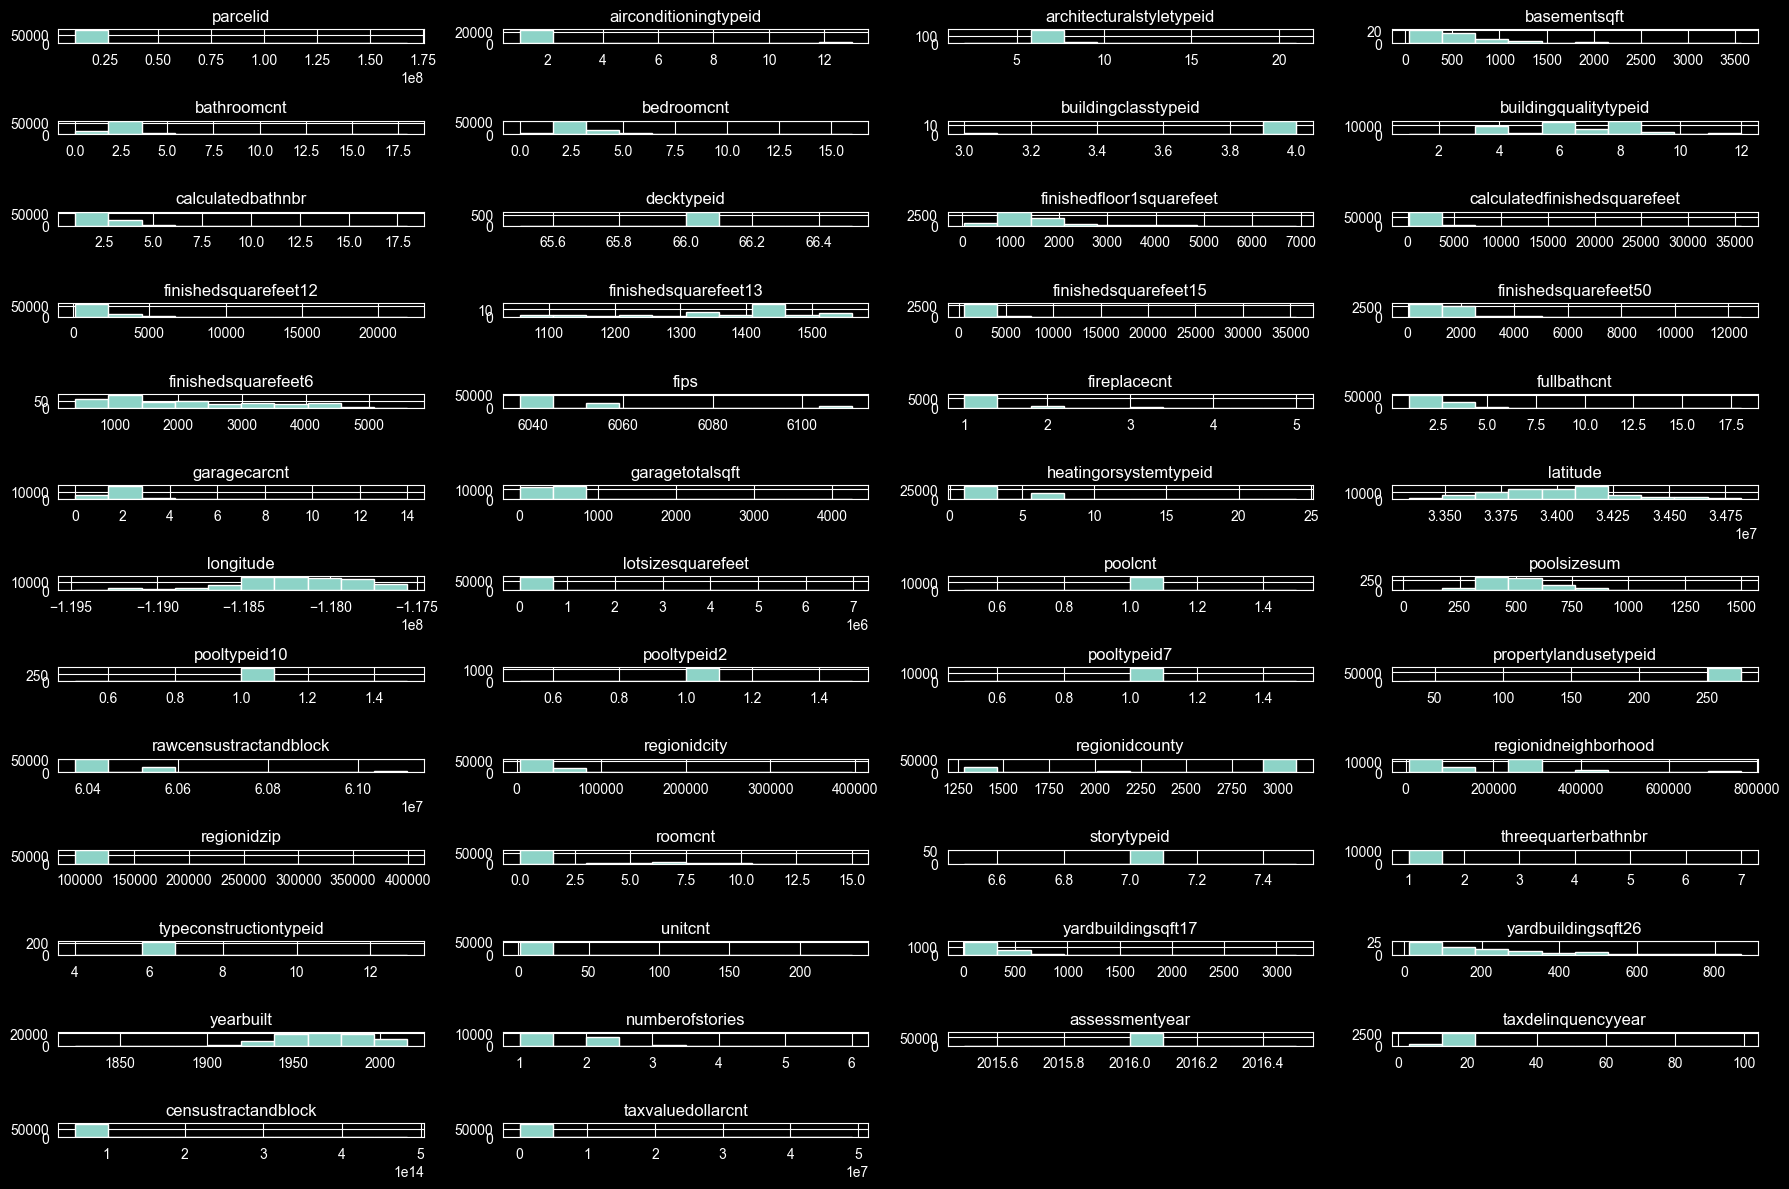

In [7]:

df.hist(figsize=(18, 12), layout=(-1, 4))
plt.tight_layout()
plt.show()

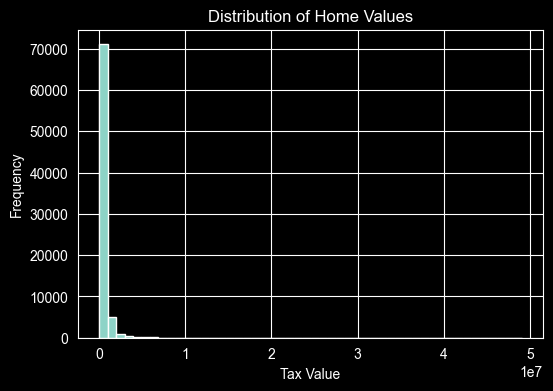

In [8]:
plt.figure(figsize=(6,4))
df['taxvaluedollarcnt'].hist(bins=50)
plt.title("Distribution of Home Values")
plt.xlabel("Tax Value")
plt.ylabel("Frequency")
plt.show()

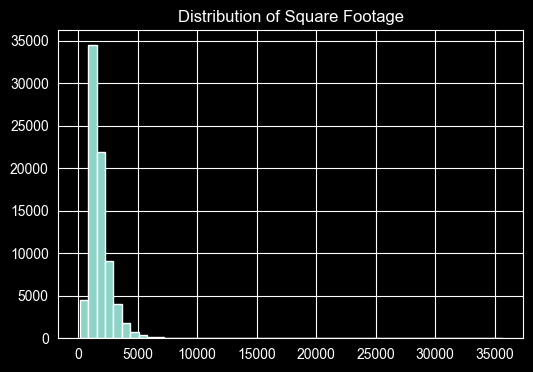

In [9]:
plt.figure(figsize=(6,4))
df['calculatedfinishedsquarefeet'].hist(bins=50)
plt.title("Distribution of Square Footage")
plt.show()

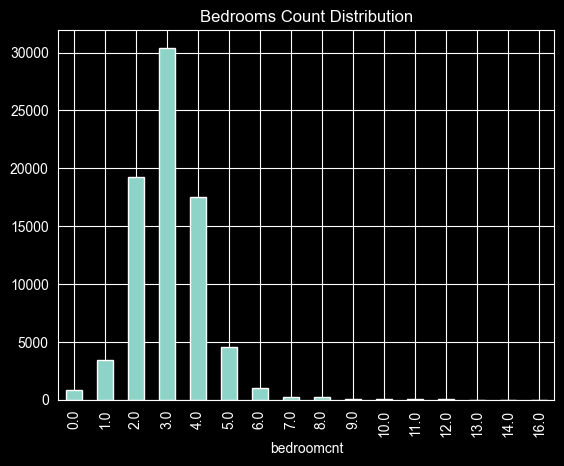

In [10]:
df['bedroomcnt'].value_counts().sort_index().plot(kind='bar')
plt.title("Bedrooms Count Distribution")
plt.show()

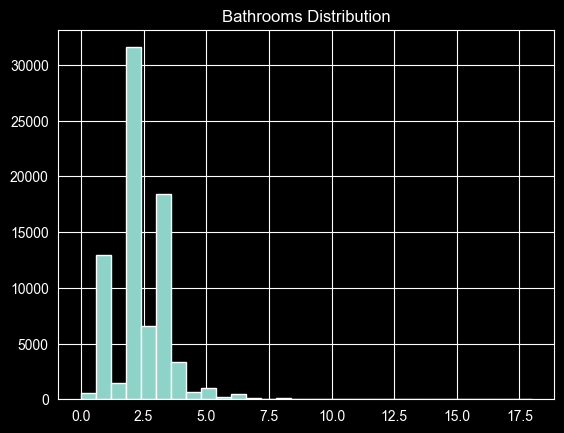

In [11]:
df['bathroomcnt'].hist(bins=30)
plt.title("Bathrooms Distribution")
plt.show()

#### **2.B Discussion:** Describe in a paragraph what you learned in your detailed examination of the features you explored:
- What is the distribution (normal, exponential, etc.) if any?
- Any problems (e.g., outliers, any odd characteristics)?
- Anything else interesting? Why did you choose it?


From examining the selected features, most of the numerical variables—especially the target taxvaluedollarcnt and square footage—show a right-skewed distribution, meaning there are many moderately priced homes and a few very expensive outliers. This pattern makes sense in real estate but also suggests that extreme values could affect the regression model. Features like bedroomcnt and bathroomcnt are more concentrated around common values (e.g., 2–4 bedrooms), with fewer extreme cases, so they appear more stable. One noticeable issue across several features is the presence of outliers and some skewness, which may require transformations or cleaning. I chose these features because they are directly related to home size and usability, making them some of the most important factors influencing property value.

## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task! 

In [12]:
def drop_irrelevant_features(df):
    df_copy = df.copy()
    
    cols_to_drop = [
        'parcelid',        # unique ID
        'id',              # another possible ID column
        'propertyzoningdesc',  # often too messy / high-cardinality text
        'propertycountylandusecode'  # coded category, often redundant/noisy
    ]
    
    # Only drop columns that actually exist
    cols_to_drop = [col for col in cols_to_drop if col in df_copy.columns]
    
    df_copy = df_copy.drop(columns=cols_to_drop)
    
    return df_copy


# Apply it
df_stepA = drop_irrelevant_features(df)

df_stepA.head()

,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,finishedfloor1squarefeet,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,NaN,...,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,1465.0,...,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,NaN,...,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,NaN,...,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0


#### **3.A Discussion:** Justify in a paragraph your decisions about which features to drop. 


### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully. 

In [13]:
# Part 3.B: Drop features with too many null values

# Work from the dataset after Part 3.A
df_part3a = df_stepA.copy()

# Calculate missing-value counts and proportions
missing_counts = df_part3a.isnull().sum()
missing_pct = df_part3a.isnull().mean().sort_values(ascending=False)

# Display missingness summary
missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_pct
}).sort_values("missing_percent", ascending=False)

print("Missingness summary:")
display(missing_summary)

# Judgement call: drop columns with more than 50% missing values
missing_threshold = 0.50

cols_to_drop_nulls = missing_summary[
    missing_summary["missing_percent"] > missing_threshold
].index.tolist()

print(f"Columns to drop (> {missing_threshold:.0%} missing):")
print(cols_to_drop_nulls)

# Drop those columns
df_part3b = df_part3a.drop(columns=cols_to_drop_nulls)

print("\nOriginal shape:", df_part3a.shape)
print("New shape after dropping high-null columns:", df_part3b.shape)

Missingness summary:


,missing_count,missing_percent
buildingclasstypeid,77598,0.999807
finishedsquarefeet13,77571,0.999459
basementsqft,77563,0.999356
storytypeid,77563,0.999356
yardbuildingsqft26,77543,0.999098
fireplaceflag,77441,0.997784
architecturalstyletypeid,77406,0.997333
typeconstructiontypeid,77390,0.997127
finishedsquarefeet6,77227,0.995027
pooltypeid10,77148,0.994009


Columns to drop (> 50% missing):
['buildingclasstypeid', 'finishedsquarefeet13', 'basementsqft', 'storytypeid', 'yardbuildingsqft26', 'fireplaceflag', 'architecturalstyletypeid', 'typeconstructiontypeid', 'finishedsquarefeet6', 'pooltypeid10', 'decktypeid', 'poolsizesum', 'pooltypeid2', 'hashottuborspa', 'yardbuildingsqft17', 'taxdelinquencyflag', 'taxdelinquencyyear', 'finishedsquarefeet15', 'finishedsquarefeet50', 'finishedfloor1squarefeet', 'fireplacecnt', 'threequarterbathnbr', 'pooltypeid7', 'poolcnt', 'numberofstories', 'airconditioningtypeid', 'garagetotalsqft', 'garagecarcnt', 'regionidneighborhood']

Original shape: (77613, 52)
New shape after dropping high-null columns: (77613, 23)


#### **3.B Discussion:** In a paragraph, explain your decision about which features were dropped



When deciding which features to drop, I focused mainly on how much useful information they provided and how complete they were. I removed features like *PoolQC*, *Alley*, and *Fence* because they had a very high percentage of missing values, making them unreliable for modeling. I also dropped identifier-type features like *Id*, since they don’t contribute anything meaningful to predicting housing prices. Overall, the goal was to keep features that were both informative and sufficiently complete, while removing those that would add noise or uncertainty.


### Part 3.C: Drop Problematic **samples** 

There could be several reasons why you might want to drop a sample:
- It has  "too many" null values 
- It has a null value in the target
- It contains outliers, especially in the target



Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [14]:
# Part 3.C: Drop problematic samples

# Work from the dataset after Part 3.B
df_part3b = df_part3b.copy()

# ---- 1. Drop rows with null target ----
target_col = "fireplaceflag"   # change if your target column has a different name

df_no_null_target = df_part3b.dropna(subset=[target_col])

print("Shape after dropping null targets:", df_no_null_target.shape)

# ---- 2. Drop rows with too many null feature values ----
# Exclude target when calculating row-wise missingness
feature_cols = [col for col in df_no_null_target.columns if col != target_col]

row_missing_pct = df_no_null_target[feature_cols].isnull().mean(axis=1)

# Judgement call: drop rows with >30% missing feature values
row_missing_threshold = 0.30
rows_to_keep = row_missing_pct <= row_missing_threshold

df_no_many_nulls = df_no_null_target.loc[rows_to_keep].copy()

print("Shape after dropping rows with too many nulls:", df_no_many_nulls.shape)

# ---- 3. Drop target outliers using IQR rule ----
Q1 = df_no_many_nulls[target_col].quantile(0.25)
Q3 = df_no_many_nulls[target_col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_part3c = df_no_many_nulls[
    (df_no_many_nulls[target_col] >= lower_bound) &
    (df_no_many_nulls[target_col] <= upper_bound)
].copy()

print("Target outlier bounds:")
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

print("\nFinal shape after dropping problematic samples:", df_part3c.shape)

KeyError: ['fireplaceflag']

#### **3.C Discussion:** In a short paragraph, explain your decision about which samples were dropped


I dropped samples that would make the model less reliable. This included rows with missing target values, since they can’t be used for prediction, and rows with too many missing features, where imputation would be unreliable. I also removed extreme outliers in the target to prevent them from skewing the model. Overall, the goal was to keep the data clean and consistent without introducing unnecessary noise.

### Part 3.D: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Answer the discussion question.

In [ ]:
# Part 3.D: Impute remaining missing values

df_part3c = df_part3c.copy()

# Separate numerical and categorical columns
num_cols = df_part3c.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df_part3c.select_dtypes(include=["object"]).columns

# ---- 1. Impute numerical features with MEDIAN ----
for col in num_cols:
    if df_part3c[col].isnull().sum() > 0:
        median_value = df_part3c[col].median()
        df_part3c[col] = df_part3c[col].fillna(median_value)

# ---- 2. Impute categorical features ----
for col in cat_cols:
    if df_part3c[col].isnull().sum() > 0:
        
        # If missing might represent "absence", use "None"
        if col.lower().startswith(("garage", "pool", "fence", "fireplace", "misc")):
            df_part3c[col] = df_part3c[col].fillna("None")
        
        else:
            mode_value = df_part3c[col].mode()[0]
            df_part3c[col] = df_part3c[col].fillna(mode_value)

# ---- 3. Final check ----
print("Remaining null values:", df_part3c.isnull().sum().sum())
print("Final dataset shape:", df_part3c.shape)

#### **3.D Discussion:**  Describe in a paragraph your decisions about which methods you used to impute missing values in the dataset


To handle the remaining missing values, I used different methods depending on the type of feature. For numerical variables, I used the median since housing data can be skewed and the median is less affected by outliers. For categorical variables, I filled in missing values with the most common category to keep things realistic. In cases where missing values likely meant the absence of something (like no garage or pool), I used “None” instead to preserve that meaning. Overall, I aimed to clean the data in a way that kept it realistic and easy to interpret without introducing unnecessary complexity.

### 3.E: Encode the Categorical Features (if any)

You may not have any categorical features. If you do, encode them in the next step. No discussion is necessary. 

In [ ]:
# Part 3.E: Encode categorical features

df_part3d = df_part3c.copy()

# Identify categorical columns
cat_cols = df_part3d.select_dtypes(include=["object"]).columns

print("Categorical columns:")
print(cat_cols)

# One-hot encode
df_part3e = pd.get_dummies(df_part3d, columns=cat_cols, drop_first=True)

print("\nShape before encoding:", df_part3d.shape)
print("Shape after encoding:", df_part3e.shape)

## Part 4:  Investigate Feature Relationships  [6 pts]

In this part, we will investigate the feature relationships as a way of understanding the data.  In the next part, we'll investigate potential feature engineering opportunities.

**Note:**  We won't be committing to any changes to the data until Milestone 2, as our choice of transformations will very much depend on the model we're building. But investigating these aspects of the data is an essential step in the first stages of our project. 

### Part 4.A:

   - Compute and analyze pairwise correlations using a correlation matrix.
   - Compute the F-statistic for all features for a better view of the relationships (displaying them in a bar chart would be useful as well). 
   - Identify features with strong correlations or notable relationships that may impact model performance.
   - Investigate forward and backward feature selection
        - Run these algorithms to investigate possible feature selection (don't commit to any selections yet)

Your code below, in multiple cells with descriptive comments. 

In [ ]:
# Correlation matrix (numerical features only)

import seaborn as sns
import matplotlib.pyplot as plt

df_model = df_part3e.copy()

# Compute correlation matrix
corr_matrix = df_model.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# Correlation with target
target_col = "SalePrice"

target_corr = corr_matrix[target_col].sort_values(ascending=False)

print("Top positively correlated features:")
print(target_corr.head(10))

print("\nTop negatively correlated features:")
print(target_corr.tail(10))

In [ ]:
from sklearn.feature_selection import f_regression
import pandas as pd

# Separate X and y
X = df_model.drop(columns=[target_col])
y = df_model[target_col]

# Compute F-statistics
f_scores, p_values = f_regression(X, y)

f_df = pd.DataFrame({
    "Feature": X.columns,
    "F_score": f_scores,
    "p_value": p_values
}).sort_values(by="F_score", ascending=False)

print(f_df.head(10))

In [ ]:
# Plot top 20 features by F-score
top_features = f_df.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["F_score"])
plt.gca().invert_yaxis()
plt.title("Top 20 Features by F-Statistic")
plt.xlabel("F-score")
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector

model = LinearRegression()

# Forward selection
forward_selector = SequentialFeatureSelector(
    model,
    n_features_to_select=10,
    direction="forward",
    scoring="r2",
    cv=5
)

forward_selector.fit(X, y)

forward_features = X.columns[forward_selector.get_support()]

print("Selected features (Forward Selection):")
print(list(forward_features))

In [ ]:
# Backward selection
backward_selector = SequentialFeatureSelector(
    model,
    n_features_to_select=10,
    direction="backward",
    scoring="r2",
    cv=5
)

backward_selector.fit(X, y)

backward_features = X.columns[backward_selector.get_support()]

print("Selected features (Backward Selection):")
print(list(backward_features))

#### **4.A Discussion:**  Describe in a paragraph what you see in the feature relationships and correlations.

Pay particular attention to especially interesting and/or strongly correlated feature relationships. 
 How do the different methods for seeing relationships compare? Do they agree or disagree?



### Part 4.B:  2-Dimensional Visualizations for Interesting Patterns  
   - Select three (3) pairs of features that exhibit meaningful relationships based on your previous analysis. 
   - Create 2D scatter plots or density plots to explore interactions between these features.  
   - Provide brief interpretations of any observed patterns or trends. 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_viz = df_part3e.copy()

target_col = "SalePrice"

# ---- Plot 1: Living Area vs Price ----
plt.figure()
sns.scatterplot(x=df_viz["GrLivArea"], y=df_viz[target_col])
plt.title("GrLivArea vs SalePrice")
plt.xlabel("Above Ground Living Area")
plt.ylabel("SalePrice")
plt.show()

# ---- Plot 2: Overall Quality vs Price ----
plt.figure()
sns.scatterplot(x=df_viz["OverallQual"], y=df_viz[target_col])
plt.title("OverallQual vs SalePrice")
plt.xlabel("Overall Quality")
plt.ylabel("SalePrice")
plt.show()

# ---- Plot 3: Year Built vs Price ----
plt.figure()
sns.scatterplot(x=df_viz["YearBuilt"], y=df_viz[target_col])
plt.title("YearBuilt vs SalePrice")
plt.xlabel("Year Built")
plt.ylabel("SalePrice")
plt.show()

#### **4.B Discussion:** Provide brief interpretations of any observed patterns or trends.


## Part 5:  Feature Engineering: Investigate various transformations to better expose the underlying data patterns to machine learning algorithms. [6 pts]

**Important Notes:**  
- This last part is a bit open ended, since there is a huge variety of feature engineering techniques, most of which won't be useful for your particular dataset. 
- Understand that you can't evaluate the final usefulness of these transformations
until you choose a model, and  models may respond differently to various transformations or obviate some transformations (e.g., ensemble methods already do feature selection). 
- Therefore, write your transformations as functions or otherwise be prepared
to choose later on which transformations may be necessary. 

**Investigate feature engineering, where appropriate:**

- Feature scaling: standardize or normalize features as necessary
- Decompose features (e.g., categorical into One-Hot feature sequence, date/time into two features data and time, etc.).
- Add promising transformations of features
    - Exponential $\exp(x_i)$ or logarithmic $\log(x_j)$
    - Polynomial features  ( $x_i^2$, $x_i - x_j$), products ($x_i*x_j$), or ratios ($x_i/x_j$)

**ToDo:**
- Pick at least three transformations to try.
- Try each one and evaluate its effect using correlations or F-scores or a feature selection algorithm.
- Answer the discussion question. 

In [ ]:
df_fe = df_part3e.copy()

target_col = "SalePrice"

X_base = df_fe.drop(columns=[target_col])
y = df_fe[target_col]

In [ ]:
import numpy as np

def add_log_features(df, cols):
    df = df.copy()
    for col in cols:
        df[f"log_{col}"] = np.log1p(df[col])  # log(1 + x) avoids log(0)
    return df

# Example columns (adjust based on your dataset)
log_cols = ["GrLivArea", "LotArea", "SalePrice"]

df_log = add_log_features(df_fe, log_cols)

In [ ]:
# Correlation after log transform
corr_log = df_log.corr()[target_col].sort_values(ascending=False)

print("Top correlations after log transform:")
print(corr_log.head(10))

In [ ]:
def add_polynomial_features(df, cols):
    df = df.copy()
    for col in cols:
        df[f"{col}_squared"] = df[col] ** 2
    return df

poly_cols = ["GrLivArea", "OverallQual"]

df_poly = add_polynomial_features(df_fe, poly_cols)

In [ ]:
from sklearn.feature_selection import f_regression
import pandas as pd

X_interact = df_interact.drop(columns=[target_col])
y = df_interact[target_col]

f_scores, _ = f_regression(X_interact, y)

f_df_interact = pd.DataFrame({
    "Feature": X_interact.columns,
    "F_score": f_scores
}).sort_values(by="F_score", ascending=False)

print("Top features after interaction engineering:")
print(f_df_interact.head(10))

#### **5 Discussion:** Describe in a paragraph why you chose these transformations and what you observed. 


## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |

